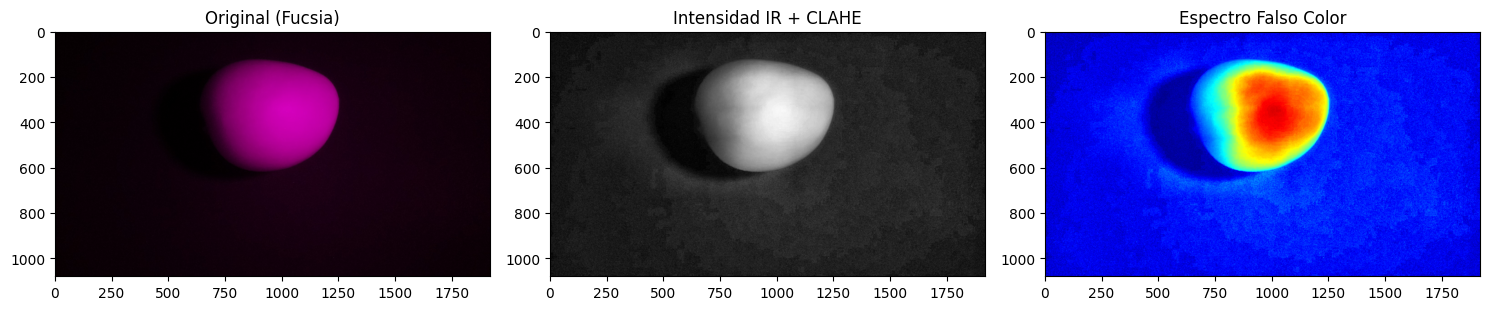

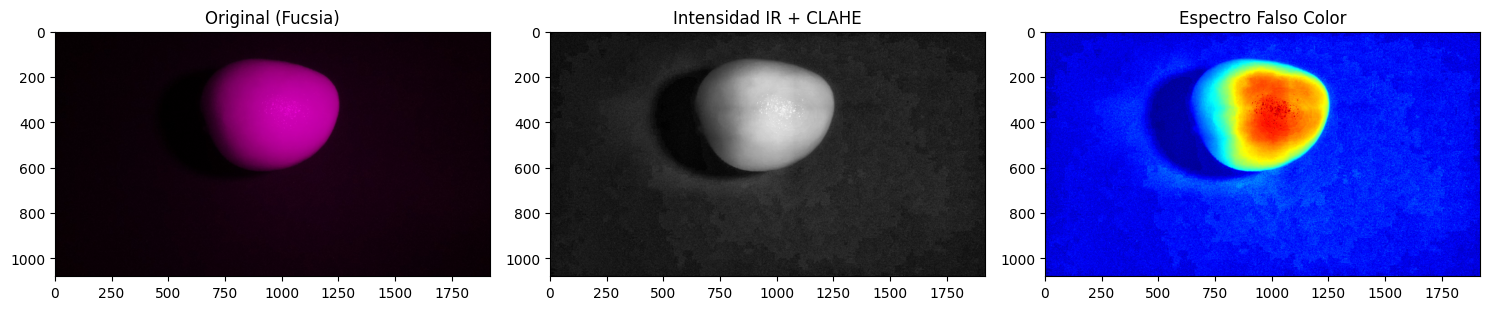

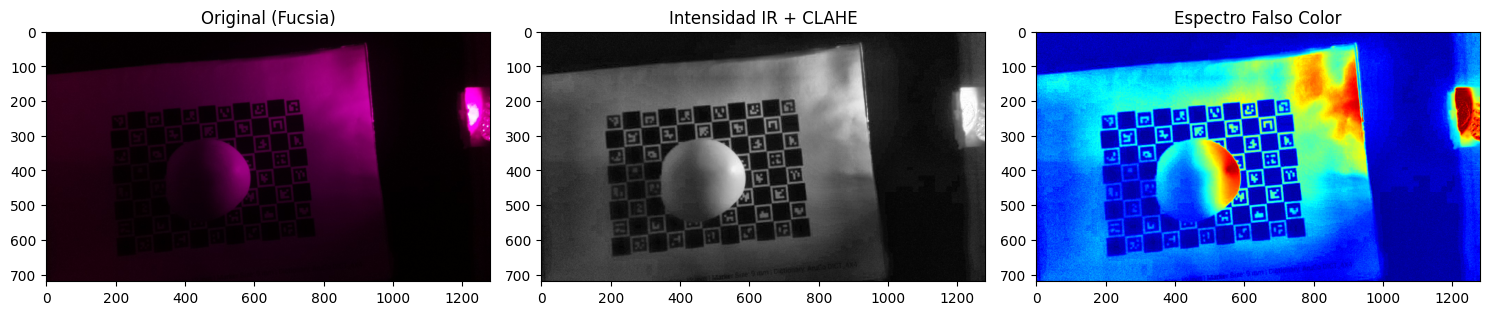

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def revelar_dano_nir(ruta_imagen):
    # 1. Leer la imagen original (Fucsia)
    img_nir = cv2.imread(ruta_imagen)
    
    # 2. Extraer el canal Rojo (En cámaras NoIR, el canal rojo captura más luz infrarroja)
    # OpenCV lee en formato BGR, por lo que el Rojo es el índice 2
    canal_ir = img_nir[:, :, 2]
    
    # 3. Ecualización del Histograma Adaptativa (CLAHE)
    # Esto es CRÍTICO para el daño mecánico: aumenta el contraste micro-local
    # para que las magulladuras oscuras resalten contra la piel sana.
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    nir_mejorado = clahe.apply(canal_ir)
    
    # 4. Mapa de Falso Color (Heatmap)
    # Transforma los grises en colores térmicos para que el ojo humano lo vea mejor.
    # El tejido dañado absorberá la luz IR (se verá azul/oscuro), el sano la refleja (rojo/amarillo).
    nir_pseudocolor = cv2.applyColorMap(nir_mejorado, cv2.COLORMAP_JET)
    
    # Visualizar
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Original (Fucsia)")
    plt.imshow(cv2.cvtColor(img_nir, cv2.COLOR_BGR2RGB))
    
    plt.subplot(1, 3, 2)
    plt.title("Intensidad IR + CLAHE")
    plt.imshow(nir_mejorado, cmap='gray')
    
    plt.subplot(1, 3, 3)
    plt.title("Espectro Falso Color")
    plt.imshow(cv2.cvtColor(nir_pseudocolor, cv2.COLOR_BGR2RGB))
    
    plt.tight_layout()
    plt.show()

# Pruébalo con tu foto
revelar_dano_nir('images/nir_2_mango.jpg')
revelar_dano_nir('images/nir_3_mango.jpg')
revelar_dano_nir('images/nir_4_mango.jpg')